In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score, precision_score, recall_score 
from sklearn.metrics import roc_auc_score, roc_curve, multilabel_confusion_matrix

import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("insurance_claims_10k.csv") 
df = df.drop(["_c39","incident_location","policy_number","insured_zip"],axis=1)
df = df.dropna(subset="fraud_reported")
df = df.drop_duplicates()
# df.shape

df['fraud_reported'] = df['fraud_reported'].replace({
    'Y': 'Yes',
    'y': 'Yes',
    'Yes': 'Yes',
    'yes': 'Yes',
    'TRUE': 'Yes',
    'true': 'Yes',
    '1': 'Yes',
    1: 'Yes',
    'Fraud': 'Yes',

    'N': 'No',
    'n': 'No',
    'No': 'No',
    'no': 'No',
    'FALSE': 'No',
    'false': 'No',
    '0': 'No',
    'Non-Fraud': 'No'
})
df['fraud_reported'].unique()
df['fraud_reported'] = df['fraud_reported'].map({'Yes': 1, 'No': 0})

In [2]:
df.info()

<class 'pandas.DataFrame'>
Index: 9711 entries, 0 to 9999
Data columns (total 36 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   months_as_customer           9585 non-null   str  
 1   age                          9486 non-null   str  
 2   policy_bind_date             9566 non-null   str  
 3   policy_state                 9661 non-null   str  
 4   policy_csl                   9653 non-null   str  
 5   policy_deductable            9650 non-null   str  
 6   policy_annual_premium        9475 non-null   str  
 7   umbrella_limit               9431 non-null   str  
 8   insured_sex                  9650 non-null   str  
 9   insured_education_level      9535 non-null   str  
 10  insured_occupation           9495 non-null   str  
 11  insured_hobbies              9581 non-null   str  
 12  insured_relationship         9596 non-null   str  
 13  capital-gains                9355 non-null   str  
 14  capital-

## Prafull

### Data Preprocessing

### Missing Values

### Column - months_as_customer

In [3]:
(df["months_as_customer"].isnull().sum() / len(df))* 100
df['months_as_customer'].describe()
# df["months_as_customer"].unique()
# df["months_as_customer"].nunique()
# df["months_as_customer"].value_counts().head(20)
(df["months_as_customer"] == "?").sum()
df["months_as_customer"] = df["months_as_customer"].replace(
    ["?", "-", "--", ""], np.nan)
df["months_as_customer"] = pd.to_numeric(
    df["months_as_customer"],
    errors="coerce"
)
df["months_as_customer"].dtype
df["months_as_customer"].min()
df["months_as_customer"].max()
(df["months_as_customer"] < 0).sum()
df.loc[
    (df["months_as_customer"] < 0) |
    (df["months_as_customer"] > 600),
    "months_as_customer"
] = np.nan
df["months_as_customer"].describe()
print("Rows whose months value repeats an earlier value:",df.duplicated().sum())
df.duplicated().sum()

Rows whose months value repeats an earlier value: 0


np.int64(0)

### IQR Outlier Analysis

In [4]:
Q1 = df["months_as_customer"].quantile(0.25)
Q3 = df["months_as_customer"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

Q1: 119.0
Q3: 280.0
IQR: 161.0
Lower bound: -122.5
Upper bound: 521.5


### Outliers

In [5]:
outliers = df[
    (df["months_as_customer"] < lower_bound) |
    (df["months_as_customer"] > upper_bound)
]
print("Number of outliers:", len(outliers))
median_months = df["months_as_customer"].median()

df["months_as_customer"] = df["months_as_customer"].fillna(
    median_months
)
df["months_as_customer"].isnull().sum()

Number of outliers: 18


np.int64(0)

### Fill Missing Values

In [6]:
median_months = df["months_as_customer"].median()

df["months_as_customer"] = df["months_as_customer"].fillna(
    median_months
)
df["months_as_customer"].isnull().sum()
# months are whole numbers so change to int
df["months_as_customer"] = df["months_as_customer"].astype(int)
df["months_as_customer"].dtype

dtype('int64')

### EDA After Cleaning

In [7]:
df.info()
df["months_as_customer"].describe()
print("Skewness:", df["months_as_customer"].skew())

<class 'pandas.DataFrame'>
Index: 9711 entries, 0 to 9999
Data columns (total 36 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   months_as_customer           9711 non-null   int64
 1   age                          9486 non-null   str  
 2   policy_bind_date             9566 non-null   str  
 3   policy_state                 9661 non-null   str  
 4   policy_csl                   9653 non-null   str  
 5   policy_deductable            9650 non-null   str  
 6   policy_annual_premium        9475 non-null   str  
 7   umbrella_limit               9431 non-null   str  
 8   insured_sex                  9650 non-null   str  
 9   insured_education_level      9535 non-null   str  
 10  insured_occupation           9495 non-null   str  
 11  insured_hobbies              9581 non-null   str  
 12  insured_relationship         9596 non-null   str  
 13  capital-gains                9355 non-null   str  
 14  capital-

### Histrogram of months_as_customer

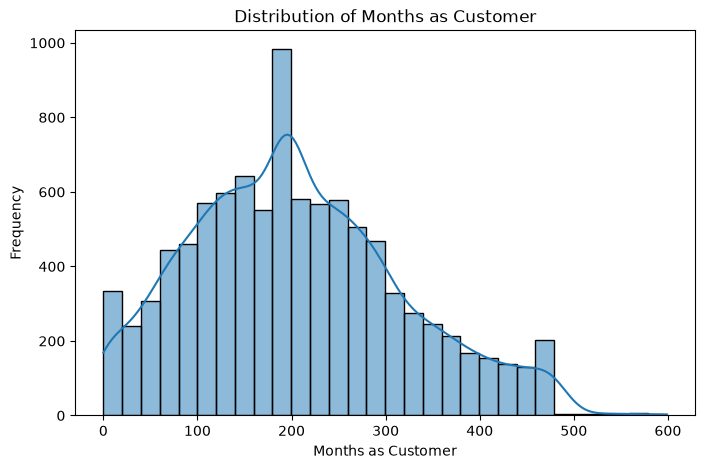

In [8]:

plt.figure(figsize=(8,5))

sns.histplot(
    df["months_as_customer"],
    bins=30,
    kde=True
)

plt.title("Distribution of Months as Customer")
plt.xlabel("Months as Customer")
plt.ylabel("Frequency")
plt.show()

### Boxplot - Months as Customer

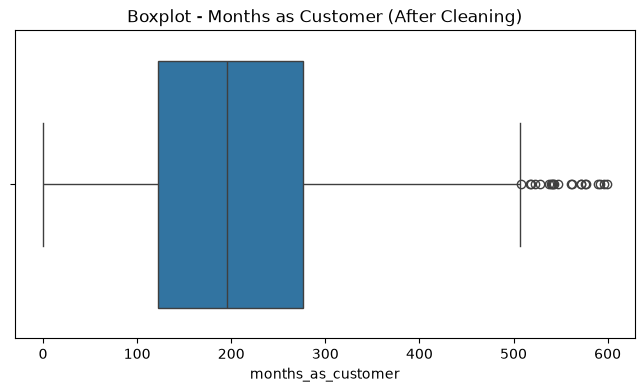

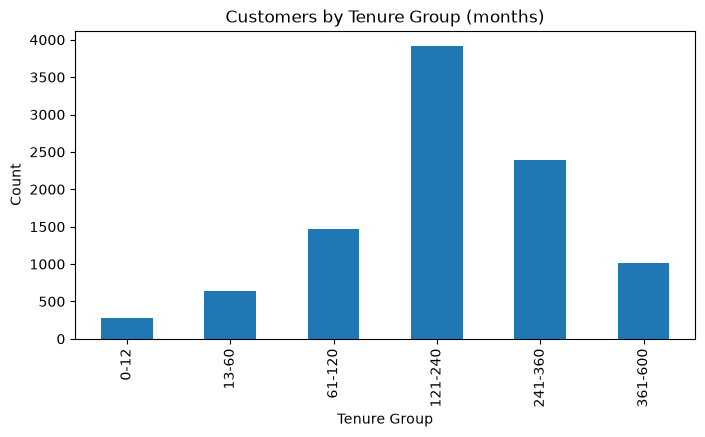

Rows in df: 9711
Null values: 0
Min: 0
Max: 599


age                  225
policy_bind_date     145
policy_state          50
policy_csl            58
policy_deductable     61
dtype: int64

In [9]:
plt.figure(figsize=(8,4))

sns.boxplot(
    x=df["months_as_customer"]
)

plt.title("Boxplot - Months as Customer (After Cleaning)")
plt.show()
tenure_group = pd.cut(
    df["months_as_customer"],
    bins=[-1, 12, 60, 120, 240, 360, 600],
    labels=["0-12", "13-60", "61-120", "121-240", "241-360", "361-600"]
)
tenure_group.value_counts().sort_index()
tenure_group.value_counts().sort_index().plot(kind="bar", figsize=(8,4))

plt.title("Customers by Tenure Group (months)")
plt.xlabel("Tenure Group")
plt.ylabel("Count")
plt.show()
print("Rows in df:", len(df))
print("Null values:", df["months_as_customer"].isnull().sum())
print("Min:", df["months_as_customer"].min())
print("Max:", df["months_as_customer"].max())

# bring the other columns into df (same rows, duplicates from the first step are already removed)
other_cols = ["age", "policy_bind_date", "policy_state", "policy_csl", "policy_deductable"]
df[other_cols] = df.loc[df.index, other_cols]

# remove extra spaces from the text values
for col in other_cols:
    df[col] = df[col].str.strip()

df.shape
df[other_cols].isnull().sum()

### Junk Values

In [10]:
# values like ?, -, -- are not real data, checking how many are there in each column
junk = ["?", "-", "--", "", "NA", "N/A", "nan", "null", "Unknown", "unknown"]

for col in other_cols:
    print(col, ":", df[col].isin(junk).sum())
df[other_cols] = df[other_cols].replace(junk, np.nan)
df[other_cols].isnull().sum()

age : 42
policy_bind_date : 30
policy_state : 21
policy_csl : 21
policy_deductable : 13


age                  267
policy_bind_date     175
policy_state          71
policy_csl            79
policy_deductable     74
dtype: int64

### 
Column - age

In [11]:
# some ages are written like 37 yrs or 35y
df["age"].str.contains("[a-zA-Z]", na=False).sum()
df["age"] = df["age"].str.replace(r"\s*(yrs|y)$", "", regex=True)

nulls_before = df["age"].isnull().sum()

df["age"] = pd.to_numeric(
    df["age"],
    errors="coerce"
)

# nothing should be lost in the conversion, so both numbers must be same
print("Nulls before conversion:", nulls_before)
print("Nulls after conversion:", df["age"].isnull().sum())
print("Dtype:", df["age"].dtype)
print("Min:", df["age"].min())
print("Max:", df["age"].max())
print("Below 18:", (df["age"] < 18).sum())
print("Above 100:", (df["age"] > 100).sum())
# age below 18 cannot have a policy and above 100 is not realistic (values like -1, 0, 5, 12, 118, 150, 999)
df.loc[
    (df["age"] < 18) |
    (df["age"] > 100),
    "age"
] = np.nan

df["age"].describe()

Nulls before conversion: 267
Nulls after conversion: 267
Dtype: float64
Min: -1.0
Max: 999.0
Below 18: 29
Above 100: 21


count    9394.000000
mean       39.019587
std         9.239531
min        19.000000
25%        32.000000
50%        38.000000
75%        45.000000
max        64.000000
Name: age, dtype: float64

### IQR Outlier Analysis - age

Q1: 32.0
Q3: 45.0
IQR: 13.0
Lower bound: 12.5
Upper bound: 64.5
Number of outliers: 0


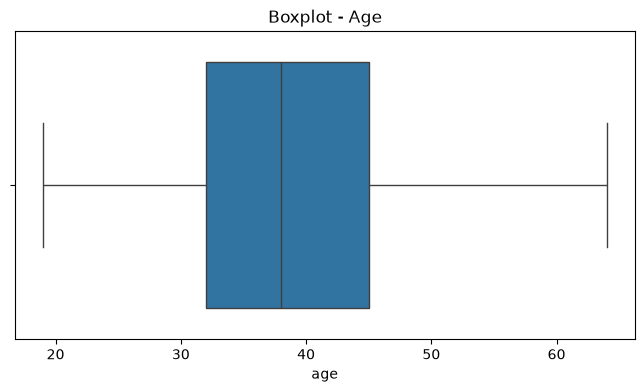

datetime64[us]
0   1990-02-25
1   1992-07-30
2   2003-01-04
3   1992-09-09
4   2013-04-05
Name: policy_bind_date, dtype: datetime64[us]


In [12]:
Q1_age = df["age"].quantile(0.25)
Q3_age = df["age"].quantile(0.75)
IQR_age = Q3_age - Q1_age

lower_age = Q1_age - 1.5 * IQR_age
upper_age = Q3_age + 1.5 * IQR_age

outliers_age = df[
    (df["age"] < lower_age) |
    (df["age"] > upper_age)
]

print("Q1:", Q1_age)
print("Q3:", Q3_age)
print("IQR:", IQR_age)
print("Lower bound:", lower_age)
print("Upper bound:", upper_age)
print("Number of outliers:", len(outliers_age))
plt.figure(figsize=(8,4))

sns.boxplot(
    x=df["age"]
)

plt.title("Boxplot - Age")
plt.show()
# # Column - policy_bind_date
# # checking the different date formats (9 = digit, M = month name)
# df["policy_bind_date"].str.replace(r"\d", "9", regex=True).str.replace(r"[A-Za-z]+", "M", regex=True).value_counts()
# date_formats = [
#     "%Y-%m-%d", "%Y/%m/%d", "%Y%m%d",
#     "%d/%m/%Y", "%m-%d-%Y", "%d.%m.%Y",
#     "%d-%b-%Y", "%b %d, %Y", "%B %d, %Y"
# ]

# bind_date = pd.Series(pd.NaT, index=df.index, dtype="datetime64[ns]")

# for fmt in date_formats:
#     temp = pd.to_datetime(df["policy_bind_date"], format=fmt, errors="coerce")
#     temp = temp.where(temp.dt.year >= 1900)   # year like 1015 is a typo
#     bind_date = bind_date.fillna(temp)

# # values which could not be converted
# df.loc[df["policy_bind_date"].notna() & bind_date.isna(), "policy_bind_date"].value_counts()
# # these are impossible dates (31-04-2015, 2015-13-05, 2015-02-30, 00/00/0000) and year 1015, so they stay as null
# df["policy_bind_date"] = bind_date

# print("Min:", df["policy_bind_date"].min())
# print("Max:", df["policy_bind_date"].max())
# print("Nulls:", df["policy_bind_date"].isnull().sum())
# df["policy_bind_date"].value_counts().head(5)
# # policies per month near the end of the data
# df["policy_bind_date"].dt.to_period("M").value_counts().sort_index().loc["2014-10":"2015-06"]
# df.loc[
#     (df["policy_bind_date"] == "1990-01-01") |
#     (df["policy_bind_date"] > "2015-03-01"),
#     "policy_bind_date"
# ] = pd.NaT

# print("Min:", df["policy_bind_date"].min())
# print("Max:", df["policy_bind_date"].max())
# print("Nulls:", df["policy_bind_date"].isnull().sum())

# Convert to datetime handling mixed formats automatically
df['policy_bind_date'] = pd.to_datetime(
    df['policy_bind_date'], format='mixed', dayfirst=True, errors='coerce'
)

# Verify the result and new data type
print(df['policy_bind_date'].dtypes)
print(df['policy_bind_date'].head())

# Extract datetime features
df['policy_bind_year'] = df['policy_bind_date'].dt.year
df['policy_bind_month'] = df['policy_bind_date'].dt.month
df['policy_bind_day'] = df['policy_bind_date'].dt.day

# df["policy_bind_year"] = df["policy_bind_date"].dt.year.astype("Int64")
# df["policy_bind_month"] = df["policy_bind_date"].dt.month.astype("Int64")
# df["policy_bind_day"] = df["policy_bind_date"].dt.day.astype("Int64")

### 
Column - policy_state

In [13]:
df["policy_state"].value_counts()
df["policy_state"] = df["policy_state"].str.upper().replace(
    {"ILLINOIS": "IL", "INDIANA": "IN", "OHIO": "OH", "IND.": "IN"})

df["policy_state"].value_counts(dropna=False)
# Column - policy_csl
df["policy_csl"].value_counts()
# same limit is written in many ways (250/500, $250K/$500K, 250-500, 100 / 300, $500K/$1M ...) so making one format
csl = df["policy_csl"].str.upper()
csl = csl.str.replace(r"[\$,\s]", "", regex=True)
csl = csl.str.replace("-", "/")
csl = csl.str.replace(r"(?<=\d)K", "", regex=True)
csl = csl.str.replace("1M", "1000")

csl.value_counts()
valid_csl = ["100/300", "250/500", "500/1000"]

# what is left outside the 3 valid limits
csl[csl.notna() & ~csl.isin(valid_csl)].value_counts()
df["policy_csl"] = csl.where(csl.isin(valid_csl))
df["policy_csl"].value_counts(dropna=False)

policy_csl
250/500     3454
100/300     3301
500/1000    2865
NaN           91
Name: count, dtype: int64

### Column - policy_deductable

In [14]:
df["policy_deductable"].value_counts()
# removing $ and , (like $1,000) and converting to numeric
df["policy_deductable"] = df["policy_deductable"].str.replace(r"[\$,]", "", regex=True)

nulls_before = df["policy_deductable"].isnull().sum()

df["policy_deductable"] = pd.to_numeric(
    df["policy_deductable"],
    errors="coerce"
)

print("Nulls before conversion:", nulls_before)
print("Nulls after conversion:", df["policy_deductable"].isnull().sum())
df["policy_deductable"].value_counts(dropna=False)
Q1_ded = df["policy_deductable"].quantile(0.25)
Q3_ded = df["policy_deductable"].quantile(0.75)
IQR_ded = Q3_ded - Q1_ded

lower_ded = Q1_ded - 1.5 * IQR_ded
upper_ded = Q3_ded + 1.5 * IQR_ded

outliers_ded = df[
    (df["policy_deductable"] < lower_ded) |
    (df["policy_deductable"] > upper_ded)
]

print("Lower bound:", lower_ded)
print("Upper bound:", upper_ded)
print("Number of outliers:", len(outliers_ded))
# Column - policy_number (duplicate check and drop)¶
# # different formats like 123456, POL-123456, P123456, 123456.0
# df["policy_number"].str.replace(r"\d", "9", regex=True).value_counts()
# # keeping only the 6 digit number so all formats become the same
# df["policy_number"] = df["policy_number"].str.extract(r"(\d{6})")[0]

# print("Nulls:", df["policy_number"].isnull().sum())
# print("Unique:", df["policy_number"].nunique())
# print("Repeated policy numbers:", (df["policy_number"].notna() & df["policy_number"].duplicated()).sum())
# repeated = df[
#     df["policy_number"].notna() &
#     df["policy_number"].duplicated(keep=False)
# ].sort_values("policy_number")

# repeated.head(6)
# # if these are the same record, age, date, state, csl and deductable should not differ inside a policy number
# repeated.groupby("policy_number")[["age", "policy_bind_date", "policy_state", "policy_csl", "policy_deductable"]].nunique().max()
# df["missing_count"] = df.isnull().sum(axis=1)
# df = df.sort_values("missing_count")

# dup_policy = df["policy_number"].notna() & df["policy_number"].duplicated()
# print("Duplicate rows removed:", dup_policy.sum())

# df = df[~dup_policy].sort_index()
# df = df.drop(columns="missing_count")
# df.shape
# df = df.drop(columns="policy_number")
# df.columns

Nulls before conversion: 74
Nulls after conversion: 74
Lower bound: -1750.0
Upper bound: 4250.0
Number of outliers: 0


### 
Fill Missing Values

In [15]:
df.isnull().sum()
median_age = df["age"].median()
df["age"] = df["age"].fillna(median_age).astype(int)

median_deductable = df["policy_deductable"].median()
df["policy_deductable"] = df["policy_deductable"].fillna(median_deductable).astype(int)

mode_state = df["policy_state"].mode()[0]
df["policy_state"] = df["policy_state"].fillna(mode_state)

mode_csl = df["policy_csl"].mode()[0]
df["policy_csl"] = df["policy_csl"].fillna(mode_csl)

median_date = df["policy_bind_date"].median()
df["policy_bind_date"] = df["policy_bind_date"].fillna(median_date)

print("Median age:", median_age)
print("Median deductable:", median_deductable)
print("Mode state:", mode_state)
print("Mode csl:", mode_csl)
print("Median bind date:", median_date)
df.isnull().sum()

Median age: 38.0
Median deductable: 1000.0
Mode state: OH
Mode csl: 250/500
Median bind date: 2002-04-08 00:00:00


months_as_customer                0
age                               0
policy_bind_date                  0
policy_state                      0
policy_csl                        0
policy_deductable                 0
policy_annual_premium           236
umbrella_limit                  280
insured_sex                      61
insured_education_level         176
insured_occupation              216
insured_hobbies                 130
insured_relationship            115
capital-gains                   356
capital-loss                    393
incident_date                    30
incident_type                    45
collision_type                  177
incident_severity               101
authorities_contacted          1107
incident_state                   47
incident_city                   123
incident_hour_of_the_day        154
number_of_vehicles_involved      98
property_damage                 241
bodily_injuries                 178
witnesses                       215
police_report_available     

### New Columns for Model

In [16]:
# policy age in years (till 2015-03-01, end of the claim period)
df["policy_age_years"] = ((pd.Timestamp("2015-03-01") - df["policy_bind_date"]).dt.days / 365).round(2)

df["policy_bind_year"] = df["policy_bind_date"].dt.year

# 250/500 -> 250 per person and 500 per accident
df[["csl_per_person", "csl_per_accident"]] = df["policy_csl"].str.split("/", expand=True).astype(int)

df[["policy_bind_date", "policy_age_years", "policy_bind_year", "policy_csl", "csl_per_person", "csl_per_accident"]].head()

,policy_bind_date,policy_age_years,policy_bind_year,policy_csl,csl_per_person,csl_per_accident
0,1990-02-25,25.03,1990,250/500,250,500
1,1992-07-30,22.60,1992,100/300,100,300
2,2003-01-04,12.16,2003,500/1000,500,1000
3,1992-09-09,22.49,1992,500/1000,500,1000
4,2013-04-05,1.90,2013,500/1000,500,1000


### EDA After Cleaning

<class 'pandas.DataFrame'>
Index: 9711 entries, 0 to 9999
Data columns (total 42 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   months_as_customer           9711 non-null   int64         
 1   age                          9711 non-null   int64         
 2   policy_bind_date             9711 non-null   datetime64[us]
 3   policy_state                 9711 non-null   str           
 4   policy_csl                   9711 non-null   str           
 5   policy_deductable            9711 non-null   int64         
 6   policy_annual_premium        9475 non-null   str           
 7   umbrella_limit               9431 non-null   str           
 8   insured_sex                  9650 non-null   str           
 9   insured_education_level      9535 non-null   str           
 10  insured_occupation           9495 non-null   str           
 11  insured_hobbies              9581 non-null   str           

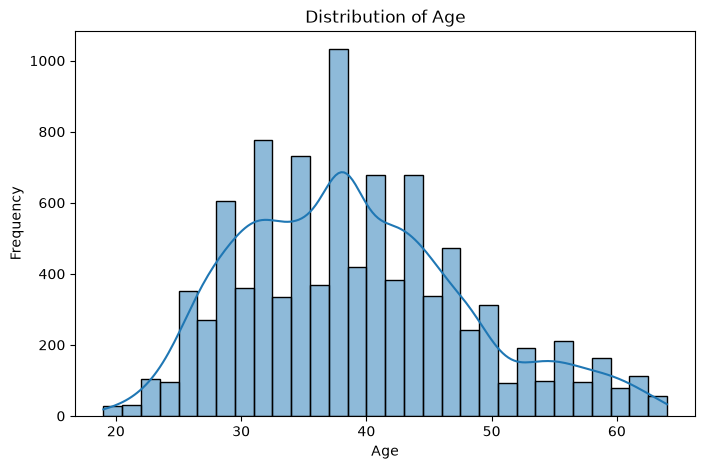

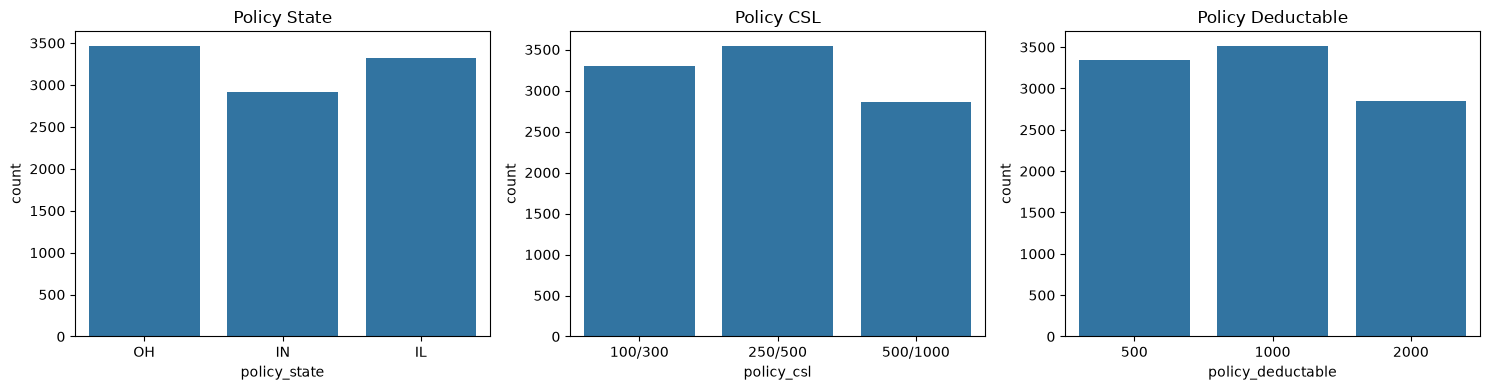

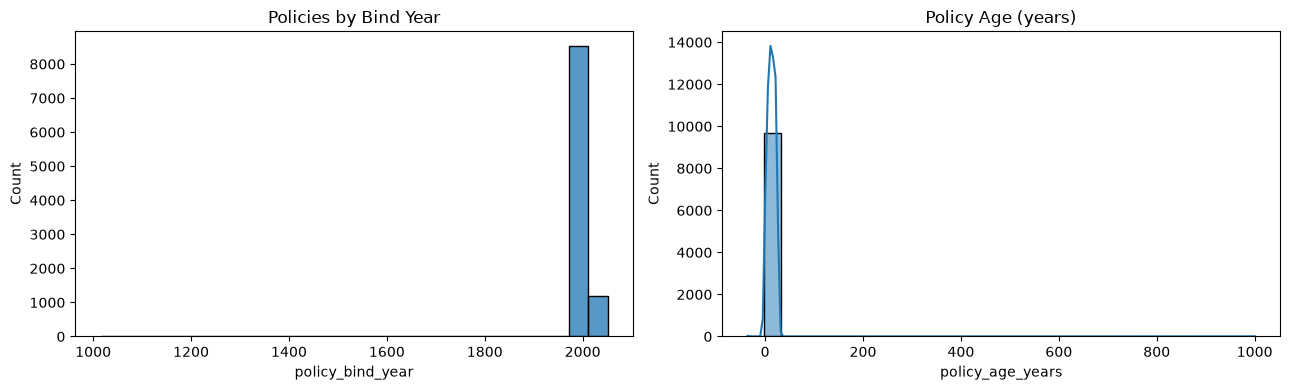

In [17]:
df.info()
df.describe()
print(df["policy_state"].value_counts())
print()
print(df["policy_csl"].value_counts())
print()
print(df["policy_deductable"].value_counts())
plt.figure(figsize=(8,5))

sns.histplot(
    df["age"],
    bins=30,
    kde=True
)

plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()
fig, axes = plt.subplots(1, 3, figsize=(15,4))

sns.countplot(x=df["policy_state"], ax=axes[0])
axes[0].set_title("Policy State")

sns.countplot(x=df["policy_csl"], order=["100/300", "250/500", "500/1000"], ax=axes[1])
axes[1].set_title("Policy CSL")

sns.countplot(x=df["policy_deductable"], ax=axes[2])
axes[2].set_title("Policy Deductable")

plt.tight_layout()
plt.show()
fig, axes = plt.subplots(1, 2, figsize=(13,4))

sns.histplot(df["policy_bind_year"], bins=26, ax=axes[0])
axes[0].set_title("Policies by Bind Year")

sns.histplot(df["policy_age_years"], bins=30, kde=True, ax=axes[1])
axes[1].set_title("Policy Age (years)")

plt.tight_layout()
plt.show()

In [18]:
df["months_as_customer"] = pd.to_numeric(
    df["months_as_customer"],
    errors="coerce"
)
df["age"] = pd.to_numeric(
    df["age"],
    errors="coerce"
)

# average customer tenure and age for each state and csl limit
print(df.groupby("policy_state")[["months_as_customer", "age"]].mean().round(1))
print()
print(df.groupby("policy_csl")[["months_as_customer", "age"]].mean().round(1))

              months_as_customer   age
policy_state                          
IL                         202.8  38.8
IN                         205.4  38.9
OH                         207.5  39.2

            months_as_customer   age
policy_csl                          
100/300                  206.8  39.1
250/500                  204.9  39.0
500/1000                 203.9  38.9


In [19]:
print("Rows in df_clean:", len(df))
print("Total null values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
df.dtypes

Rows in df_clean: 9711
Total null values: 6192
Duplicate rows: 0


months_as_customer                      int64
age                                     int64
policy_bind_date               datetime64[us]
policy_state                              str
policy_csl                                str
policy_deductable                       int64
policy_annual_premium                     str
umbrella_limit                            str
insured_sex                               str
insured_education_level                   str
insured_occupation                        str
insured_hobbies                           str
insured_relationship                      str
capital-gains                             str
capital-loss                              str
incident_date                             str
incident_type                             str
collision_type                            str
incident_severity                         str
authorities_contacted                     str
incident_state                            str
incident_city                     

In [20]:
# saving the cleaned data
df.to_csv("insurance_first7_cleaned.csv", index=False)

## Kanchan

#### policy_annual_premium

In [21]:
df['policy_premium'] = df['policy_annual_premium'].copy()

In [22]:
df['policy_premium'] = df['policy_premium'].replace({
                                                    "null":np.nan,
                                                     "NULL":np.nan,
                                                     "N/A":np.nan,
                                                     "#NA":np.nan,
                                                     "?":np.nan,
                                                     "--":np.nan,
                                                     "":np.nan,
                                                     " ":np.nan
})

In [23]:
col = "policy_annual_premium"

# ---------- BEFORE: check ----------
print("Dtype before:", df[col].dtype)

# ---------- Step 1: Convert text to numbers (?, -, --, blank -> NaN) ----------
df[col] = (
    df[col]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("$", "", regex=False)
    .str.strip()
)
df[col] = pd.to_numeric(df[col], errors="coerce")   # keeps decimals like 1313.25
# print("Dtype after conversion:", df[col].dtype)
# print("Missing after conversion:", df[col].isna().sum())

# ---------- Step 2: Fix negative values (sign error) ----------
df["premium_fixed_flag"] = (df[col] < 0).astype(int)
# print("Negative values found:", (df[col] < 0).sum())
df[col] = df[col].abs()

# ---------- Step 3: Fix scale error (e.g. 124972 -> 1249.72) ----------
# print("Extreme values (>10000):", (df[col] > 10000).sum())
df.loc[df[col] > 10000, col] /= 100

# ---------- Step 4: 0 and 1 are not real premiums -> NaN ----------
print("Values <= 1:", (df[col] <= 1).sum())
df.loc[df[col] <= 1, col] = np.nan

# ---------- Step 5: Fill missing values with median ----------
print("Total missing before fill:", df[col].isna().sum())
median_val = df[col].median()
df[col] = df[col].fillna(median_val).round(2)

# ---------- Step 6: Outliers (IQR) ----------
Q1, Q3 = df[col].quantile([0.25, 0.75])
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
n_out = ((df[col] < lower) | (df[col] > upper)).sum()
print(f"Outliers: {n_out} ({n_out / len(df) * 100:.2f}%) | limits: {lower:.2f} to {upper:.2f}")

df["premium_capped"] = df[col].clip(lower=lower, upper=upper)

# ---------- Step 7: Verify ----------
print("\n--- FINAL CHECK ---")
print("Dtype:", df[col].dtype)
print("Negatives left:", (df[col] < 0).sum())
print("Missing left:", df[col].isna().sum())
print("Min:", df[col].min(), "| Max:", df[col].max())
print(df[col].describe())

Dtype before: str
Values <= 1: 26
Total missing before fill: 412
Outliers: 129 (1.33%) | limits: 615.01 to 1886.71

--- FINAL CHECK ---
Dtype: float64
Negatives left: 0
Missing left: 0
Min: 62.31 | Max: 9325.0
count    9711.000000
mean     1253.506779
std       265.048978
min        62.310000
25%      1091.895000
50%      1258.820000
75%      1409.820000
max      9325.000000
Name: policy_annual_premium, dtype: float64


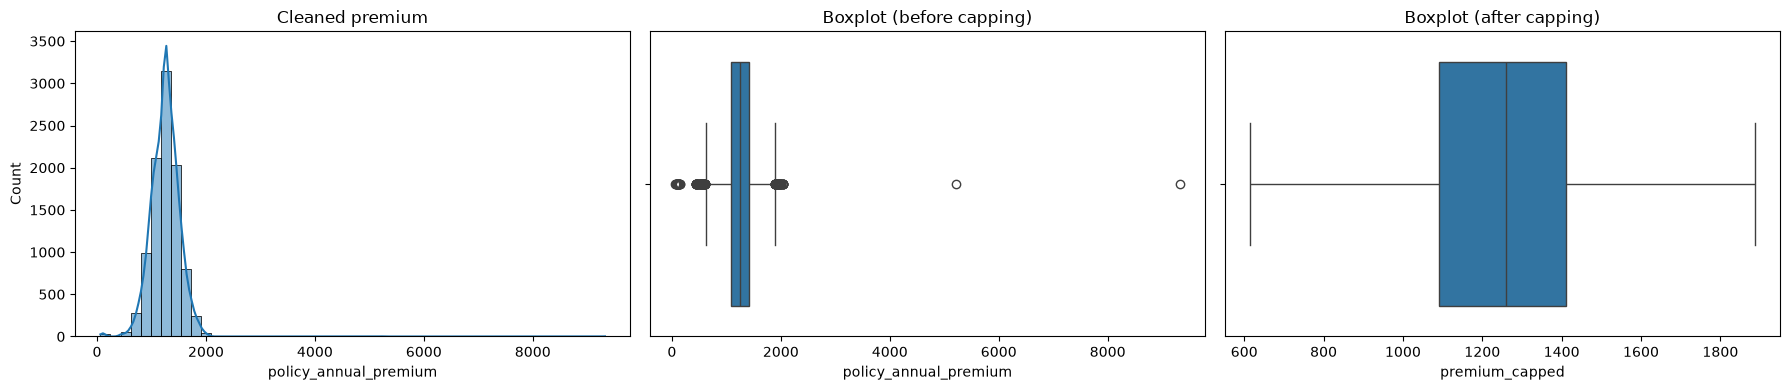

In [24]:
# ---------- Step 8: Plots before vs after capping ----------
fig, ax = plt.subplots(1, 3, figsize=(18, 4))
sns.histplot(df[col], bins=50, kde=True, ax=ax[0]);  ax[0].set_title("Cleaned premium")
sns.boxplot(x=df[col], ax=ax[1]);                    ax[1].set_title("Boxplot (before capping)")
sns.boxplot(x=df["premium_capped"], ax=ax[2]);       ax[2].set_title("Boxplot (after capping)")
plt.tight_layout()
plt.show()

#### insured_sex

In [25]:
df['insured_sex'].unique()
df['insured_sex'] = df['insured_sex'].str.strip().str.upper()
clean_data = {
               'FEMALE': 'Female', 
                'F':'Female',
                 'FEMAL':'Female',
                 'FEMAALE': 'Female',
                 'FEALE': 'Female',
                 'FEMLE': 'Female',
                 'FEMLAE': 'Female', 
                 'FEMMALE': 'Female',
                 'FEMALLE': 'Female',
                 'FEAMLE': 'Female',
                  'EFMALE': 'Female',
                  'FMALE' : 'Female',
                  'FEMAE' : 'Female',
                  'FEEMALE': 'Female', 
                   'MALE': 'Male',
                    '?' : 'Unknown',
                   'M' : 'Male',
                   np.nan:'Unknown',
                  'MLE':'Male',
                  'AMLE':'Male',
                  'MALLE':'Male',
                   '-':'Unknown',
                   'MAALE':'Male',
                 'MAE':'Male',
                 'UNKNOWN': 'Unknown',
                  'MLAE' :'Male',
                  '':'Unknown'
                   
} 
df['insured_sex'] = df['insured_sex'].replace(clean_data)
# pd.get_dummies(df,columns = ['insured_sex'],drop_first = True,dtype = int)

#### umbrella_limit

In [26]:
df['umbrella_limit'].duplicated()

0       False
1       False
2        True
3        True
4       False
        ...  
9995     True
9996     True
9997     True
9998     True
9999     True
Name: umbrella_limit, Length: 9711, dtype: bool

In [27]:
df['umbrella_limit'].isnull().sum()

np.int64(280)

In [28]:
df['umbrella_limit'].value_counts(dropna = False)

umbrella_limit
0              7430
6000000         551
5000000         404
4000000         355
NaN             280
7000000         225
3000000         102
0M               68
8000000          61
9000000          40
2000000          33
-                25
?                15
60,00,000        15
70,00,000        15
-1000000         14
10000000         11
50,00,000        10
40,00,000        10
-500000          10
-2000000          8
5M                6
30,00,000         5
--                5
6M                4
4M                2
1,00,00,000       1
90,00,000         1
-20,00,000        1
-5,00,000         1
80,00,000         1
8M                1
7M                1
Name: count, dtype: int64

In [29]:
df['umbrella_limit'] = df['umbrella_limit'].replace({
                                                         "?":np.nan,
                                                          "-":np.nan,
                                                           "--":np.nan,
                                                           "-2-":np.nan,
                                                            "nan":np.nan
})
df['umbrella_limit'].unique()

<StringArray>
[    '3000000',           '0',     '6000000',     '7000000',     '5000000',
          '6M',     '4000000',           nan,     '9000000',    '-1000000',
     '8000000',    '10000000',     '2000000',          '0M',   '30,00,000',
   '60,00,000',          '4M',   '50,00,000',   '40,00,000',    '-2000000',
 '1,00,00,000',          '5M',     '-500000',   '70,00,000',   '90,00,000',
  '-20,00,000',   '-5,00,000',   '80,00,000',          '8M',          '7M']
Length: 30, dtype: str

In [30]:
has_M = df['umbrella_limit'].astype(str).str.contains("M",na=False)
#convert to string first
df['umbrella_limit'] = df['umbrella_limit'].astype(str)
#Remove M
df['umbrella_limit'] = df['umbrella_limit'].str.replace("M","",regex=False)
#Remove Commas:
df['umbrella_limit'] = df['umbrella_limit'].str.replace(",","",regex=False)
##Convert to numeric
df['umbrella_limit'] = pd.to_numeric(df['umbrella_limit'],errors="coerce")
#convert M values into Actual millions
df.loc[has_M,'umbrella_limit'] *=1000000
#handle negative values:
df.loc[df['umbrella_limit']<0,'umbrella_limit']=np.nan
#calculate median using only positive values
median_limit = df.loc[df['umbrella_limit'] > 0,'umbrella_limit'].median()
#fill missing  values with positive value median
df['umbrella_limit'] = df['umbrella_limit'].fillna(median_limit)

In [31]:
df['umbrella_limit'].unique

<bound method Series.unique of 0       3000000.0
1             0.0
2             0.0
3             0.0
4       6000000.0
          ...    
9995          0.0
9996          0.0
9997    5000000.0
9998          0.0
9999          0.0
Name: umbrella_limit, Length: 9711, dtype: float64>

In [32]:
# df['umbrella_limit'].isnull().sum()
# print("Positive median:", median_limit)
# print(df['umbrella_limit'].describe())
# print(df['umbrella_limit'].isna().sum())

In [33]:
# print("Missing values:", df['umbrella_limit'].isna().sum())
# print("Negative values:", (df['umbrella_limit'] < 0).sum())
# # print("Data type:", df['umbrella_limit'].dtype)

#### insured_education_level

In [34]:
df['insured_education_level'].unique

<bound method Series.unique of 0         Associate
1               NaN
2       High School
3           Masters
4       High School
           ...     
9995             JD
9996            PhD
9997        Masters
9998             MD
9999             JD
Name: insured_education_level, Length: 9711, dtype: str>

In [35]:
# df['insured_education_level'] = df['insured_education_level'].drop_duplicates(keep="first").reset_index=True
# df.duplicated().sum()

In [36]:
df['insured_education_level'].value_counts(dropna = False)

insured_education_level
High School     1376
JD              1277
MD              1215
Associate       1189
Masters         1170
                ... 
Assocciate         1
High  School       1
Coollege           1
Assciate           1
Cllege             1
Name: count, Length: 77, dtype: int64

In [37]:
# Step 1: Convert all values to lowercase for consistency
df['insured_education_level'] = df['insured_education_level'].str.lower()

# Step 2: Strip whitespace
df['insured_education_level'] = df['insured_education_level'].str.strip()

# Step 3: Replace common variations and typos

replace_map = {
    "high-school": "high school",
    "highschool": "high school",
    "hs": "high school",
    "hgih school": "high school",
    "high schoool": "high school",
    "high  school": "high school",

    "college": "college",
    "colllege": "college",
    "colelge": "college",
    "colege": "college",
    "coollege": "college",
    "cllege": "college",

    "assoc.": "associate",
    "assoiate": "associate",
    "assoociate": "associate",
    "associte": "associate",
    "assocate": "associate",
    "assocciate": "associate",
    "assciate": "associate",
    "assoicate": "associate",
    "associates":"associate",
    "associatte":"associate",
    "assocaite":"associate",

    "mastres": "masters",
    "msaters": "masters",
    "mastes": "masters",
    "masteers": "masters",
    "master": "masters",
    "master's": "masters",
    "ms":"masters",

    "jd": "juris doctor",
    "j.d.": "juris doctor",
    "jd ": "juris doctor",

    "md": "medical doctor",
    "m.d.": "medical doctor",

    "phd": "phd",
    "ph.d": "phd",
    "doctorate": "phd",

    "na": "Unknown",
    "n/a": "Unknown",
    "null": "Unknown",
    "none": "Unknown",
    "?": "Unknown",
    "unknown": "Unknown",
    "-": "Unknown",
    "": "Unknown",
    np.nan: "Unknown"
}
    
df['insured_education_level'] = df['insured_education_level'].replace(replace_map)

# Step 4: Drop rows with missing values (optional, depending on your analysis)
# df = df.dropna(subset=['insured_education_level'])

# Step 5: Check unique values after cleaning
print(df['insured_education_level'].unique())

# Step 6: Perform EDA (example: frequency counts)
print(df['insured_education_level'].value_counts())
# Make a copy after dropping rows
# df = df.dropna(subset=["insured_education_level"]).copy()

# Now safe to encode
df["education_encoded"] = df["insured_education_level"].astype("category").cat.codes
df["education_encoded"]

<StringArray>
[     'associate',        'Unknown',    'high school',        'masters',
 'medical doctor',   'juris doctor',            'phd',        'college']
Length: 8, dtype: str
insured_education_level
high school       1574
juris doctor      1447
medical doctor    1392
associate         1349
masters           1344
phd               1181
college           1164
Unknown            260
Name: count, dtype: int64


0       1
1       0
2       3
3       5
4       3
       ..
9995    4
9996    7
9997    5
9998    6
9999    4
Name: education_encoded, Length: 9711, dtype: int8

## Suraj

### insured_relationship

In [38]:


df['insured_relationship'].unique()

df['insured_relationship'].value_counts(dropna=False)

"""
Since manually building dictionary keys for 107 items is tedious, 
I wrote a short helper script using difflib (built into Python) to automatically cluster all 107 unique values 
into their closest standard category.
----------------
Automatically Generate the typo_map Dictionary
with the help of grouping logic generated the full typo_map dictionary automatically 
so we don't need to type out each variant manually:
"""
import difflib

valid_categories = ['husband', 'wife', 'own-child', 'unmarried', 'not-in-family', 'other-relative']

# 1. First standardise whitespace, casing, and delimiters
df['insured_relationship'] = (
    df['insured_relationship']
    .astype(str)
    .str.lower()
    .str.strip()
    .str.replace('_', '-', regex=False)
    .str.replace(' ', '-', regex=False)
)

# 2. Build map automatically for remaining typos
auto_typo_map = {}

for val in df['insured_relationship'].dropna().unique():
    if val in valid_categories or val == 'nan':
        continue
    matches = difflib.get_close_matches(val, valid_categories, n=1, cutoff=0.4)
    if matches:
        auto_typo_map[val] = matches[0]

# Fix string 'nan' back to real NaN
auto_typo_map['nan'] = np.nan

# Apply the map to dataframe
df['insured_relationship'] = df['insured_relationship'].replace(auto_typo_map)

df['insured_relationship'].value_counts(dropna=False)

# List of missing/placeholder representations
missing_placeholders = ['?', 'unknown', '-', '']

# Replaced placeholders with actual NaN
df['insured_relationship'] = df['insured_relationship'].replace(missing_placeholders, np.nan)

df['insured_relationship'].value_counts(dropna=False)

# Replaced NaN values with 'Unknown'
df['insured_relationship'] = df['insured_relationship'].fillna('Unknown')

# Applied one-hot encoding
# df = pd.get_dummies(df, columns=['insured_relationship'], drop_first=True, dtype=int)

### capital-loss

<class 'pandas.Series'>
Index: 9711 entries, 0 to 9999
Series name: capital-loss
Non-Null Count  Dtype
--------------  -----
9318 non-null   str  
dtypes: str(1)
memory usage: 151.7 KB
count     9318
unique    1105
top          0
freq      4239
Name: capital-loss, dtype: object
127     999999.0
717     999999.0
960     999999.0
1448    999999.0
3013    999999.0
4144    999999.0
4342    999999.0
4379    999999.0
4955    999999.0
6652    999999.0
Name: capital-loss, dtype: float64


<Axes: xlabel='capital-loss', ylabel='Density'>

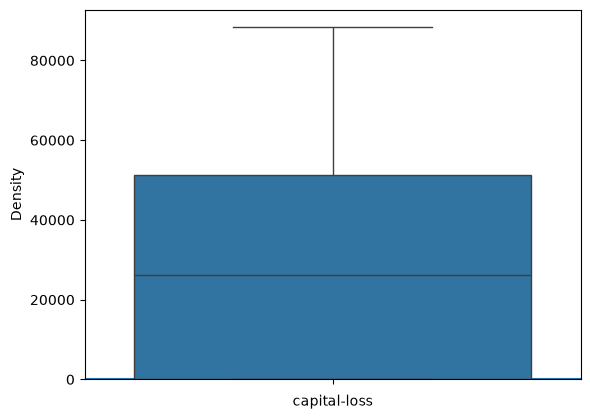

In [39]:
# Check data type and non-null count
df['capital-loss'].info()

# Summary statistics (including min, max, percentiles)
print(df['capital-loss'].describe())

#Cleaning special symbols like '$' and ','
df['capital-loss'] = (
    df['capital-loss']
    .astype(str)
    .str.replace(r'[\$,#,-]', '', regex=True)
    .str.strip()
)

#Replacing known missing string indicators with actual NaN
missing_placeholders = ['?', 'unknown', '-', '', 'nan', 'NaN', 'None']
df['capital-loss'] = df['capital-loss'].replace(missing_placeholders, np.nan)

df['capital-loss'] = pd.to_numeric(df['capital-loss'], errors='coerce')

# Impute using median
df['capital-loss'] = df['capital-loss'].fillna(df['capital-loss'].median())

# sns.kdeplot(df['capital-loss'])

# sns.boxplot(df['capital-loss'])

# Check top maximum values
print(df['capital-loss'].nlargest(10))

# Clip values below 0 to 0
df['capital-loss'] = df['capital-loss'].clip(lower=0)

# Cap extreme values at the 99th percentile
upper_limit = df['capital-loss'].quantile(0.99)
df['capital-loss'] = np.where(df['capital-loss'] > upper_limit, upper_limit, df['capital-loss'])

sns.kdeplot(df['capital-loss'])

sns.boxplot(df['capital-loss'])

### capital-gains

<class 'pandas.Series'>
Index: 9711 entries, 0 to 9999
Series name: capital-gains
Non-Null Count  Dtype
--------------  -----
9355 non-null   str  
dtypes: str(1)
memory usage: 151.7 KB
count     9355
unique    1043
top          0
freq      4403
Name: capital-gains, dtype: object
Missing values: 356
91      9999999.0
1251    9999999.0
2688    9999999.0
2831    9999999.0
3635    9999999.0
5993    9999999.0
8016    9999999.0
8142    9999999.0
8248    9999999.0
9066    9999999.0
Name: capital-gains, dtype: float64


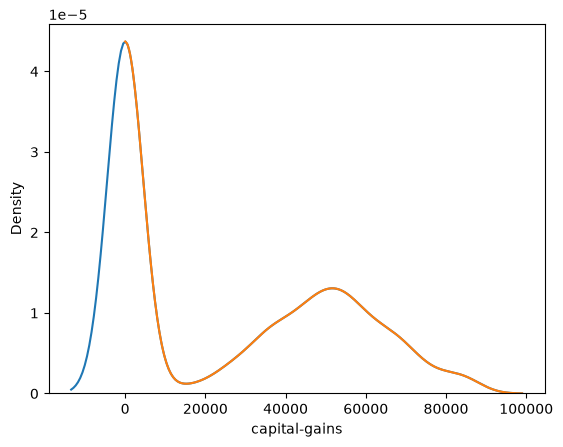

<Axes: ylabel='capital-gains'>

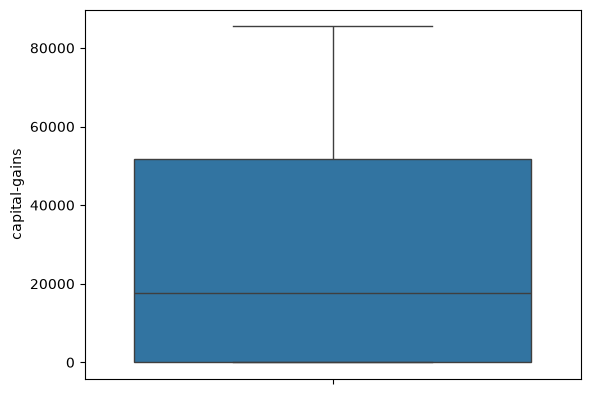

In [40]:
# Check data type and non-null count
df['capital-gains'].info()

# Summary statistics (including min, max, percentiles)
print(df['capital-gains'].describe())

# Check count of missing values
print("Missing values:", df['capital-gains'].isnull().sum())

#Cleaning special symbols like '$' and ','
df['capital-gains'] = (
    df['capital-gains']
    .astype(str)
    .str.replace(r'[\$,#,-]', '', regex=True)
    .str.strip()
)

#Replacing known missing string indicators with actual NaN
missing_placeholders = ['?', 'unknown', '-', '', 'nan', 'NaN', 'None']
df['capital-gains'] = df['capital-gains'].replace(missing_placeholders, np.nan)

df['capital-gains'] = pd.to_numeric(df['capital-gains'], errors='coerce')

# sns.kdeplot(df['capital-gains'])

# sns.boxplot(df['capital-gains'])

# Check top maximum values
print(df['capital-gains'].nlargest(10))

# Clip values below 0 to 0
df['capital-gains'] = df['capital-gains'].clip(lower=0)

# Cap extreme values at the 99th percentile
upper_limit = df['capital-gains'].quantile(0.99)
df['capital-gains'] = np.where(df['capital-gains'] > upper_limit, upper_limit, df['capital-gains'])

sns.kdeplot(df['capital-gains'])

#Clip the KDE curve explicitly at [0, upper_limit]
sns.kdeplot(df['capital-gains'], clip=(0, None))
plt.show()

sns.boxplot(df['capital-gains'])

### incident_date

In [41]:
df['incident_date'].info()

df['incident_date'].describe()

# Convert to datetime handling mixed formats automatically
df['incident_date'] = pd.to_datetime(
    df['incident_date'], format='mixed', dayfirst=True, errors='coerce'
)

# Check count of missing/invalid dates
missing_dates = df['incident_date'].isna().sum()
print(f"Total missing dates: {missing_dates}")

"""
Machine learning models cannot directly take datetime objects. 
Once converted to datetime, extract useful numeric feature components:
"""
# Extract datetime features
df['incident_year'] = df['incident_date'].dt.year.astype("Int64")
df['incident_month'] = df['incident_date'].dt.month.astype("Int64")
df['incident_day'] = df['incident_date'].dt.day.astype("Int64")
df['incident_dayofweek'] = df['incident_date'].dt.dayofweek.astype("Int64")  # 0=Monday, 6=Sunday
df['incident_is_weekend'] = (
    df['incident_dayofweek'].isin([5, 6]).astype(int)
)  # Useful for claim risk analysis

<class 'pandas.Series'>
Index: 9711 entries, 0 to 9999
Series name: incident_date
Non-Null Count  Dtype
--------------  -----
9681 non-null   str  
dtypes: str(1)
memory usage: 151.7 KB
Total missing dates: 55


### incident_type

In [42]:
df['incident_type'].info()

df['incident_type'].describe()

df['incident_type'].unique()



import difflib

# 1. Define the exact target categories
valid_categories = [
    'Single Vehicle Collision',
    'Multi-vehicle Collision',
    'Parked Car',
    'Vehicle Theft'
]

# 2. Step 1: Pre-clean whitespace and normalize formatting
# Convert to string, lowercase, strip spaces, and normalize underscores/extra spaces
df['incident_type_clean'] = (
    df['incident_type']
    .astype(str)
    .str.strip()
    .str.replace(r'\s+', ' ', regex=True)
)

# Replace common unknown/null placeholders with NaN upfront
invalid_placeholders = ['nan', 'None', 'null', '?', '-', 'Unknown', ' ', '']
df['incident_type_clean'] = df['incident_type_clean'].replace(invalid_placeholders, np.nan)

# 3. Step 2: Build auto_typo_map using difflib
auto_typo_map = {}

# Convert valid categories to lowercase for matching
valid_categories_lower = [cat.lower() for cat in valid_categories]

for val in df['incident_type_clean'].dropna().unique():
    val_lower = val.lower()
    
    # Check close matches using string similarity
    matches = difflib.get_close_matches(val_lower, valid_categories_lower, n=1, cutoff=0.4)
    
    if matches:
        # Find index of matched lower string to get the correctly capitalized category
        matched_idx = valid_categories_lower.index(matches[0])
        auto_typo_map[val] = valid_categories[matched_idx]

# 4. Step 3: Map mapped values back onto the clean column
df['incident_type'] = df['incident_type_clean'].map(auto_typo_map)

# Remove temporary clean working column
df.drop(columns=['incident_type_clean'], inplace=True)

# 5. Step 4: Verify the output
print("Unique categories remaining:", df['incident_type'].nunique())
print(df['incident_type'].value_counts(dropna=False))

# Replaced NaN values with 'Unknown'
df['incident_type'] = df['incident_type'].fillna('Unknown')

# df['incident_type'].unique()

# Applied one-hot encoding
# df = pd.get_dummies(df, columns=['incident_type'], drop_first=False, dtype=int)

#droping "incident_type_Unknown" column
# df.drop(columns=['incident_type_Unknown'], inplace=True)

# Verified one-hot encoded Feature by filtering all dummy columns created for incident_type
# encoded_cols_incident_type = [col for col in df.columns if col.startswith('incident_type')]
# print(encoded_cols_incident_type)

<class 'pandas.Series'>
Index: 9711 entries, 0 to 9999
Series name: incident_type
Non-Null Count  Dtype
--------------  -----
9666 non-null   str  
dtypes: str(1)
memory usage: 151.7 KB
Unique categories remaining: 4
incident_type
Multi-vehicle Collision     3970
Single Vehicle Collision    3897
Vehicle Theft                923
Parked Car                   858
NaN                           63
Name: count, dtype: int64


### collision_type

In [43]:
df['collision_type'].info()

df['collision_type'].describe()

df['collision_type'].unique()

import difflib

# 1. Define the exact target categories
valid_categories = ["Front Collision", "Rear Collision", "Side Collision"]

# 2. Step 1: Pre-clean whitespace and normalize formatting
df['collision_type_clean'] = (
    df['collision_type']
    .astype(str)
    .str.strip()
    .str.replace(r'\s+', ' ', regex=True)
)

# Replace common unknown/null placeholders with NaN upfront
invalid_placeholders = ['nan', 'None', 'null', '?', '-', 'Unknown','unknown', ' ', '']
df['collision_type_clean'] = df['collision_type_clean'].replace(invalid_placeholders, np.nan)

# 3. Step 2: Build auto_typo_map using difflib
auto_typo_map = {}
valid_categories_lower = [cat.lower() for cat in valid_categories]

for val in df['collision_type_clean'].dropna().unique():
    val_lower = val.lower()
    matches = difflib.get_close_matches(val_lower, valid_categories_lower, n=1, cutoff=0.4)
    if matches:
        matched_idx = valid_categories_lower.index(matches[0])
        auto_typo_map[val] = valid_categories[matched_idx]

# 4. Step 3: Map cleaned values onto collision_type using replace to preserve unmatched valid entries
df['collision_type'] = df['collision_type_clean'].replace(auto_typo_map)

# Remove temporary clean working column
df.drop(columns=['collision_type_clean'], inplace=True)

# 5. Step 4: Verify output
print("Unique categories remaining:", df['collision_type'].nunique())
print(df['collision_type'].value_counts(dropna=False))

# Replaced NaN values with 'Unknown'
df['collision_type'] = df['collision_type'].fillna('Unknown')

# df['collision_type'].unique()

# Applied one-hot encoding
# df = pd.get_dummies(df, columns=['collision_type'], drop_first=False, dtype=int)

#droping "collision_type_Unknown" column
# df.drop(columns=['collision_type_Unknown'], inplace=True)

# Verified one-hot encoded Feature by filtering all dummy columns created for collision_type
# encoded_cols_collision_type = [col for col in df.columns if col.startswith('collision_type')]
# print(encoded_cols_collision_type)

<class 'pandas.Series'>
Index: 9711 entries, 0 to 9999
Series name: collision_type
Non-Null Count  Dtype
--------------  -----
9534 non-null   str  
dtypes: str(1)
memory usage: 151.7 KB
Unique categories remaining: 3
collision_type
Rear Collision     2738
Side Collision     2603
Front Collision    2371
NaN                1999
Name: count, dtype: int64


### incident_severity

In [44]:

df['incident_severity'].info()

df['incident_severity'].describe()

df['incident_severity'].unique()

import difflib

# 1. Define the exact target categories
valid_categories = ["Major Damage", "Minor Damage", "Trivial Damage", "Total Loss", ]

# 2. Step 1: Pre-clean whitespace and normalize formatting
df['incident_severity_clean'] = (
    df['incident_severity']
    .astype(str)
    .str.strip()
    .str.replace(r'\s+', ' ', regex=True)
)

# Replace common unknown/null placeholders with NaN upfront
invalid_placeholders = ['nan', 'None', 'null', '?', '-', 'Unknown','unknown', ' ', '']
df['incident_severity_clean'] = df['incident_severity_clean'].replace(invalid_placeholders, np.nan)

# 3. Step 2: Build auto_typo_map using difflib
auto_typo_map = {}
valid_categories_lower = [cat.lower() for cat in valid_categories]

for val in df['incident_severity_clean'].dropna().unique():
    val_lower = val.lower()
    matches = difflib.get_close_matches(val_lower, valid_categories_lower, n=1, cutoff=0.4)
    if matches:
        matched_idx = valid_categories_lower.index(matches[0])
        auto_typo_map[val] = valid_categories[matched_idx]

# 4. Step 3: Map cleaned values onto collision_type using replace to preserve unmatched valid entries
df['incident_severity'] = df['incident_severity_clean'].replace(auto_typo_map)

# Remove temporary clean working column
df.drop(columns=['incident_severity_clean'], inplace=True)

# 5. Step 4: Verify output
print("Unique categories remaining:", df['incident_severity'].nunique())
print(df['incident_severity'].value_counts(dropna=False))

# Replaced NaN values with 'Unknown'
df['incident_severity'] = df['incident_severity'].fillna('Unknown')

df['incident_severity'].unique()

# Applied one-hot encoding
# df = pd.get_dummies(df, columns=['incident_severity'], drop_first=False, dtype=int)

#droping "incident_severity_Unknown" column
# df.drop(columns=['incident_severity_Unknown'], inplace=True)

# Verified one-hot encoded Feature by filtering all dummy columns created for incident_severity
# encoded_cols_incident_severity = [col for col in df.columns if col.startswith('incident_severity')]
# print(encoded_cols_incident_severity)

<class 'pandas.Series'>
Index: 9711 entries, 0 to 9999
Series name: incident_severity
Non-Null Count  Dtype
--------------  -----
9610 non-null   str  
dtypes: str(1)
memory usage: 151.7 KB
Unique categories remaining: 4
incident_severity
Minor Damage      3384
Major Damage      2655
Total Loss        2605
Trivial Damage     924
NaN                143
Name: count, dtype: int64


<StringArray>
['Major Damage', 'Total Loss', 'Minor Damage', 'Trivial Damage', 'Unknown']
Length: 5, dtype: str

## Mukesh

#### authorities_contacted

In [45]:


df['authorities_contacted'].nunique() # total unique count in feature 45
df['authorities_contacted'].value_counts()  # count with unique vale NAN is not count
df['authorities_contacted'].unique()  # 45 unique vale present with including wrong spelling 
df['authorities_contacted'] = df['authorities_contacted'].str.strip().str.upper()
df['authorities_contacted'] = df['authorities_contacted'].replace({"AMBULANCE SERVICE":"Ambulance",
                                                                  "AMBLUANCE":"Ambulance",
                                                                  "ABMULANCE":"Ambulance",
                                                                  "AMBULANCE":"Ambulance"})

df['authorities_contacted'] = df['authorities_contacted'].replace({"POLICE":"Police",
                                                                  "POLIE":"Police",
                                                                  "PLICE":"Police",
                                                                  "PLOICE":"Police",
                                                                  "POILCE":"Police",
                                                                  "POLICCE":"Police",
                                                                  "POLICE DEPT":"Police",
                                                                  "POLICE DEPT.":"Police"})

df['authorities_contacted'] = df['authorities_contacted'].replace({"FIRE":"Fire",             
                                                                    "IFRE":"Fire",                
                                                                    "FRIE":"Fire",            
                                                                    "FIIRE":"Fire",
                                                                    "FIRE DEPT" : "Fire",
                                                                    "FIRE BRIGADE":"Fire"})

df['authorities_contacted'] = df['authorities_contacted'].replace({"OTHER":"Other",
                                                                   "OTHERS":"Other",
                                                                   "OHTER":"Other",
                                                                   "TOHER":"Other",
                                                                   "OTEHR":"Other",})

# df['authorities_contacted'] = df['authorities_contacted'].replace({"?":"Unknown",           
#                                                                     "EMS":"Unknown",            
#                                                                     "-":"Unknown",          
#                                                                     " ":"Unknown",              
#                                                                     "UNKNOWN":"Unknown",
#                                                                     np.nan : "Unknown"})    

df['authorities_contacted'] = ( df['authorities_contacted'].astype('string').str.strip().replace({
                                                                                                    '?': 'Unknown',
                                                                                                    'EMS': 'Unknown',
                                                                                                    '-': 'Unknown',
                                                                                                    '': 'Unknown',
                                                                                                    'UNKNOWN': 'Unknown',
                                                                                                    'nan': 'Unknown'
                                                                                                    }).fillna('Unknown'))

# One Hand Encoding
# df = pd.get_dummies(df,columns=["authorities_contacted"],dtype=int)
# df

#### incident_state

In [46]:
df['incident_state'].unique()
df['incident_state'] = df['incident_state'].str.strip().str.upper()
replace_vale = {
    "WV": "West Virginia",
    "WEST VIRGINIA": "West Virginia",
    "W.VA.": "West Virginia",
    "W. VIRGINIA": "West Virginia",

    "VA": "Virginia",
    "VIRGINIA": "Virginia",

    "SC": "South Carolina",
    "SOUTH CAROLINA": "South Carolina",
    "S.C.": "South Carolina",

    "NY": "New York",
    "NEW YORK": "New York",
    "N.Y.": "New York",

    "NC": "North Carolina",
    "NORTH CAROLINA": "North Carolina",
    "N.C.": "North Carolina",

    "PA": "Pennsylvania",
    "PENNSYLVANIA": "Pennsylvania",
    "PENN.": "Pennsylvania",

    "OH": "Ohio",
    "OHIO": "Ohio"
}
df['incident_state'] = df['incident_state'].replace(replace_vale) # spelling miss correct value are converted into correct value
df['incident_state'] = df['incident_state'].replace({"?":"Unknown","UNKNOWN":"Unknown","-":"Unknown","":"Unknown"}) #replace the invalid/missing values 
df['incident_state'] = df['incident_state'].fillna('Unknown') #filling the null value with Unknown value
# df = pd.get_dummies(df,columns=['incident_state'],drop_first=True,dtype=int)
# df.info()

#### incident_hour_of_the_day

In [47]:
def convert_into_hour(x):
    if pd.isna(x):
        return np.nan

    x = str(x).strip().upper()

    if x in ["", "--", "?"]:
        return np.nan

    if ":" in x:
        return int(x.split(":")[0])

    if "AM" in x or "PM" in x:
        return pd.to_datetime(x, format="%I %p").hour

    try:
        return int(float(x))
    except:
        return np.nan


df["incident_hour_of_the_day"] = df["incident_hour_of_the_day"].apply(convert_into_hour)

df['incident_hour_of_the_day'] = df['incident_hour_of_the_day'].replace([-1, 99,24,25], np.nan)
df['incident_hour_of_the_day'] = df['incident_hour_of_the_day'].fillna(df['incident_hour_of_the_day'].median())
df["incident_hour_of_the_day"].astype(int)

0       12
1       16
2       10
3       17
4        3
        ..
9995     7
9996     1
9997     0
9998    13
9999     3
Name: incident_hour_of_the_day, Length: 9711, dtype: int64

#### number_of_vehicles_involved

In [48]:
df['number_of_vehicles_involved'].unique()

word_to_num = {
        "One": 1,
        "Two": 2,
        "Three": 3,
        "Four": 4
}

df['number_of_vehicles_involved'] = (df['number_of_vehicles_involved'].replace(['--', '?', '-'], np.nan))
df['number_of_vehicles_involved'] = pd.to_numeric(df['number_of_vehicles_involved'],errors='coerce')
df['number_of_vehicles_involved'] = df['number_of_vehicles_involved'].replace(word_to_num)
df['number_of_vehicles_involved'] = ( df['number_of_vehicles_involved'].fillna(df['number_of_vehicles_involved'].median()))

# sns.boxplot(df['number_of_vehicles_involved'])

Q1 = df['number_of_vehicles_involved'].quantile(0.25)
Q3 = df['number_of_vehicles_involved'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df['number_of_vehicles_involved'] = df['number_of_vehicles_involved'].clip(lower=lower, upper=upper)

df['number_of_vehicles_involved'] = df['number_of_vehicles_involved'].astype(int)

#### property_damage

In [49]:
df['property_damage'] = df['property_damage'].str.strip().str.upper()
df['property_damage'] = df['property_damage'].replace({"YES":"Yes",
                                                       'Y':"Yes",
                                                       '1':"Yes",
                                                        "TRUE":"Yes",
                                                         "NO":"No",
                                                      "N":"No",
                                                      "FALSE":"No",
                                                      "0":"No",
                                                      "?":"Unknown",
                                                      "UNKNOWN":"Unknown",
                                                      "-":"Unknown",
                                                      " ":"Unknown",
                                                      np.nan:"Unknown"})
# df = pd.get_dummies(df,columns=["property_damage"],drop_first=True,dtype=int)
# df

#### 8 bodily_injuries

<Axes: ylabel='bodily_injuries'>

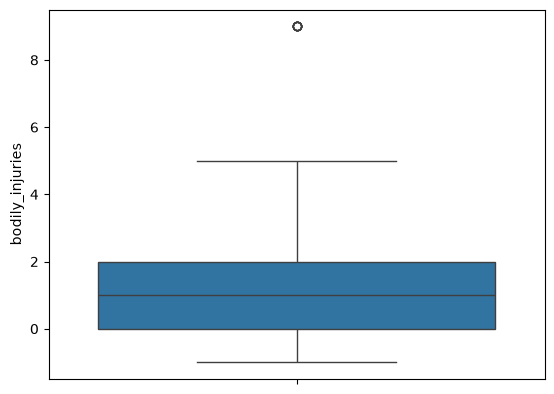

In [50]:
df['bodily_injuries'] = (df['bodily_injuries'].replace({'-': np.nan, '--': np.nan, '?': np.nan, -1: np.nan}).pipe(pd.to_numeric, errors='coerce'))
df['bodily_injuries'] = df['bodily_injuries'].fillna(df['bodily_injuries'].median())
df['bodily_injuries'] = df['bodily_injuries'].astype(int) #Convert back to integer
sns.boxplot(df['bodily_injuries'])

<Axes: xlabel='bodily_injuries', ylabel='Density'>

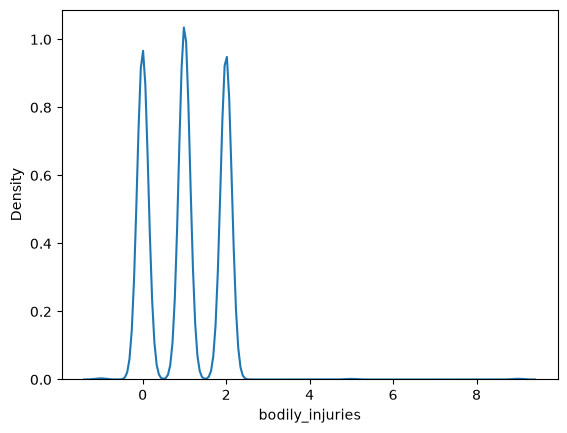

In [51]:


sns.kdeplot(df['bodily_injuries'])

<Axes: ylabel='bodily_injuries'>

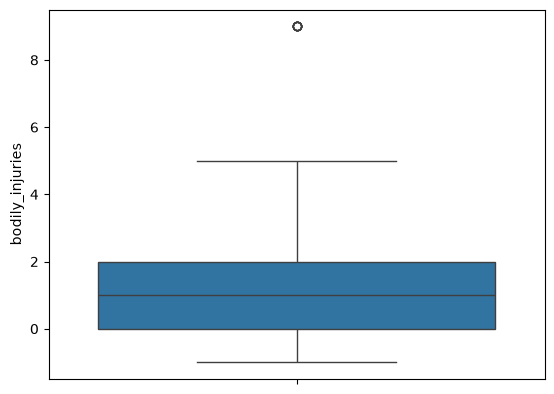

In [52]:
sns.boxplot(df['bodily_injuries'])

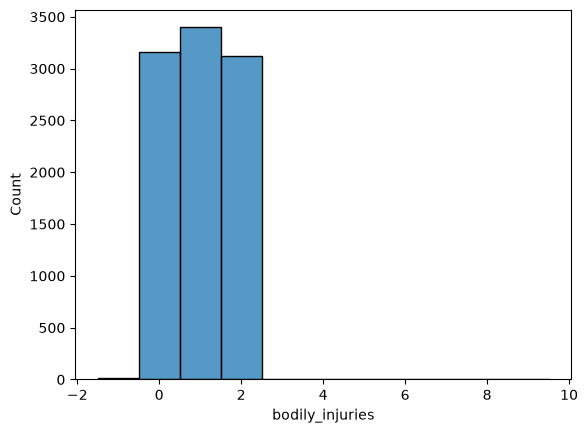

In [53]:
sns.histplot(data=df, x='bodily_injuries', discrete=True)
plt.show()

## 
Pooja

### witnesses

In [54]:
df['witnesses']

df['witnesses'].unique() 

df['witnesses'] = df['witnesses'].replace(['?', '-', '--'], np.nan)  #Convert invalid symbols to NaN

df['witnesses'].value_counts(dropna=False)

df['witnesses'] = pd.to_numeric(df['witnesses'], errors='coerce')  #Convert column to numeric

df.loc[df['witnesses'] < 0, 'witnesses'] = np.nan  #replace -1 into nan

df.loc[~df['witnesses'].isin([0, 1, 2, 3]), 'witnesses'] = np.nan # repalce 12 and 99 into nan

median_witnesses = df['witnesses'].median()

df['witnesses'] = df['witnesses'].fillna(median_witnesses)

df['witnesses'] = df['witnesses'].astype(int)

df['witnesses'].value_counts().sort_index()

witnesses
0    2324
1    2364
2    2708
3    2315
Name: count, dtype: int64

### police_report_available

In [55]:
df['police_report_available'] 

# check Unique values 
df['police_report_available'].unique() 

df['police_report_available'].value_counts(dropna=False) 
#Check how many YES, NO, and ? values are present.

df['police_report_available'] = df['police_report_available'].str.strip() #Remove extra spaces

df['police_report_available'] = df['police_report_available'].str.upper()  
#Convert everything to uppercase

df['police_report_available'] = df['police_report_available'].replace(['Y', '1', 'TRUE'], 'YES')
# replace in YES

df['police_report_available'] = df['police_report_available'].replace(['N', '0', 'FALSE'], 'NO') 
# replace in NO

 #Convert invalid values to NaN
df['police_report_available'] = df['police_report_available'].replace( ['-', 'UNKNOWN', '', '?'], np.nan)

#Fill missing values with mode
df['police_report_available'].mode()[0]

df['police_report_available'] =df['police_report_available'].fillna( df['police_report_available'].mode()[0])

# df['police_report_available'].value_counts()

#df = pd.get_dummies(df,columns=["police_report_available"],drop_first=True,dtype=int)

### total_claim_amount

In [56]:
df['total_claim_amount']

df['total_claim_amount'].unique() 

df['total_claim_amount'].value_counts(dropna=False)

#Remove $ and commas 
df['total_claim_amount'] = df['total_claim_amount'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False)

#Convert to numeric
df['total_claim_amount'] = pd.to_numeric( df['total_claim_amount'], errors='coerce')

#Fill missing values
df['total_claim_amount'] = df['total_claim_amount'].fillna( df['total_claim_amount'].median())

df['total_claim_amount'] = df['total_claim_amount'].astype(int)

df['total_claim_amount'].value_counts().head()

total_claim_amount
57280    248
0         31
5900       9
3290       9
4820       9
Name: count, dtype: int64

### injury_claim

In [57]:
df['injury_claim'].head()

df['injury_claim'].unique() 

#Remove $ and commas 
df['injury_claim'] = ( df['injury_claim'].str.replace('$', '', regex=False).str.replace(',', '', regex=False))

# conver to numeric
df['injury_claim'] = pd.to_numeric(df['injury_claim'], errors='coerce')

#fill the missing value
df['injury_claim'] = df['injury_claim'].fillna( df['injury_claim'].median())

# convert in int
df['injury_claim'] = df['injury_claim'].astype(int)

df['injury_claim'].head()

0    6820
1    6020
2    6200
3    6960
4    9270
Name: injury_claim, dtype: int64

### property_claim

In [58]:
df['property_claim'].head()

df['property_claim'].unique() 

df['property_claim'] = ( df['property_claim'].str.replace('$', '', regex=False).str.replace(',', '', regex=False))

df['property_claim'] = pd.to_numeric(df['property_claim'], errors='coerce')

df['property_claim'] = df['property_claim'].fillna( df['property_claim'].median())

df['property_claim'] = df['property_claim'].astype(int)

df['property_claim'].head()

0     6200
1    12030
2     6200
3    13910
4     4640
Name: property_claim, dtype: int64

### vehicle_claim

In [59]:
df['vehicle_claim'].head()

df['vehicle_claim'].value_counts().head()

df['vehicle_claim'].unique() 

df['vehicle_claim'] = ( df['vehicle_claim'].str.replace('$', '', regex=False).str.replace(',', '', regex=False))

df['vehicle_claim'] = pd.to_numeric(df['vehicle_claim'], errors='coerce')

df['vehicle_claim'] = df['vehicle_claim'].fillna( df['vehicle_claim'].median())

df['vehicle_claim'] = df['vehicle_claim'].astype(int)

df['vehicle_claim'].head()

0    55810
1    48130
2    49590
3    48680
4    32450
Name: vehicle_claim, dtype: int64

### auto_make

In [60]:

df['auto_make'].head()

df['auto_make'].unique() 
df['auto_make'] = df['auto_make'].str.strip()
df['auto_make'] = df['auto_make'].str.lower()
df['auto_make'] = df['auto_make'].replace(['?', '', '-' ,'unknown'], np.nan)

df['auto_make'] = df['auto_make'].replace({
    'suburu': 'subaru',
    'sbuuru': 'subaru',
    'subburu': 'subaru',
    'Sburu': 'subaru',
    'Subru' : 'subaru',
    'sburu' : 'subaru',
    'subru': 'subaru',
    
    'accura': 'acura',
    'accuura': 'acura',
    'accua': 'acura',

    'chevy': 'chevrolet',

    'volks wagen': 'volkswagen',
    'volkswagon': 'volkswagen',
    'vw': 'volkswagen',

    'mercedes benz': 'mercedes',
    'mercedes-benz': 'mercedes',
    'merceeds': 'mercedes',

    'jep': 'jeep',
    'ejep': 'jeep',

    'toytoa': 'toyota',
    'otyota': 'toyota',
    'Toyotta':'toyota',
    'oTyota' : 'toyota',
    'toyotta':'toyota',

    'ddoge': 'dodge',
    'ddge': 'dodge',

    'sab': 'saab',
    'asab': 'saab',

    'honnda': 'honda',
    'hondda': 'honda',
    'hodna': 'honda',
    'Hnoda':'honda',
    'hnoda': 'honda',

    'nisssan': 'nissan',
    'Nisssan': 'nissan',
    'Nissan ': 'nissan',

    'Chevvrolet':'Chevrrolet',
    'chevrrolet' : 'Chevrrolet',
    'chevrolet' : 'Chevrrolet',
    'chevvrolet':  'Chevrrolet',
    'chevvrolet':'Chevrrolet'
    
})

df['auto_make'] = df['auto_make'].fillna('Unknown')


df['auto_make'].value_counts()

auto_make
saab          792
subaru        787
dodge         739
Chevrrolet    718
nissan        702
ford          697
bmw           685
acura         673
volkswagen    665
audi          658
mercedes      646
jeep          643
toyota        622
honda         559
Unknown        98
chevrolet      27
Name: count, dtype: int64

### auto_year

In [61]:
df['auto_year'].head()

df['auto_year'].unique()
df['auto_year'] = df['auto_year'].replace(['-', '?', '--'], np.nan)
df['auto_year'] = pd.to_numeric( df['auto_year'], errors='coerce')
df.loc[ ~df['auto_year'].between(1995, 2015),'auto_year'] = np.nan
df['auto_year'] = df['auto_year'].fillna(df['auto_year'].median())
df['auto_year'] = df['auto_year'].astype("int32")
df['auto_year'].head()

0    1995
1    2014
2    1997
3    2005
4    2005
Name: auto_year, dtype: int32

In [62]:
df.shape

(9711, 51)

In [108]:
selected_columns = [
    "months_as_customer",
    "age",
    "policy_bind_year",
    "policy_bind_month",
    "policy_bind_day",
    "policy_deductable",
    "policy_age_years",
    "csl_per_person",
    "csl_per_accident",
    "policy_annual_premium",
    "umbrella_limit",
    "education_encoded",
    "capital-loss",
    "capital-gains",
    "incident_year",
    "incident_month",
    "incident_day",
    "incident_dayofweek",
    "incident_is_weekend",
    "incident_hour_of_the_day",
    "number_of_vehicles_involved", 
    "bodily_injuries",
    "witnesses",
    "total_claim_amount",
    "injury_claim",
    "property_claim",
    "vehicle_claim",
    "auto_year",

    "insured_sex",  # encoding
    "police_report_available",  # encoding
    "property_damage",   # encoding
    "authorities_contacted",  # encoding
    "incident_state",     # encoding
    "insured_relationship",   # encoding
    "incident_type",   # encoding
    "collision_type",   # encoding
    "incident_severity",  # encoding
    "fraud_reported"
]

dfs = df[selected_columns]

In [109]:
# df['policy_bind_year'].value_counts()
dfs.info()

<class 'pandas.DataFrame'>
Index: 9711 entries, 0 to 9999
Data columns (total 38 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   months_as_customer           9711 non-null   int64  
 1   age                          9711 non-null   int64  
 2   policy_bind_year             9711 non-null   int32  
 3   policy_bind_month            9524 non-null   float64
 4   policy_bind_day              9524 non-null   float64
 5   policy_deductable            9711 non-null   int64  
 6   policy_age_years             9711 non-null   float64
 7   csl_per_person               9711 non-null   int64  
 8   csl_per_accident             9711 non-null   int64  
 9   policy_annual_premium        9711 non-null   float64
 10  umbrella_limit               9711 non-null   float64
 11  education_encoded            9711 non-null   int8   
 12  capital-loss                 9711 non-null   float64
 13  capital-gains                9272 

In [110]:
print("Before:", dfs.shape)

dfs = dfs.dropna()

print("After:", dfs.shape)

Before: (9711, 38)
After: (9042, 38)


In [111]:
dfs.info()

<class 'pandas.DataFrame'>
Index: 9042 entries, 0 to 9999
Data columns (total 38 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   months_as_customer           9042 non-null   int64  
 1   age                          9042 non-null   int64  
 2   policy_bind_year             9042 non-null   int32  
 3   policy_bind_month            9042 non-null   float64
 4   policy_bind_day              9042 non-null   float64
 5   policy_deductable            9042 non-null   int64  
 6   policy_age_years             9042 non-null   float64
 7   csl_per_person               9042 non-null   int64  
 8   csl_per_accident             9042 non-null   int64  
 9   policy_annual_premium        9042 non-null   float64
 10  umbrella_limit               9042 non-null   float64
 11  education_encoded            9042 non-null   int8   
 12  capital-loss                 9042 non-null   float64
 13  capital-gains                9042 

In [112]:
#dfs = dfs[~dfs.eq("Unknown").any(axis=1)]  # if you want the other/Unknown class in our feature then Comment out otherwise run the cell

In [113]:
dfs = pd.get_dummies(dfs,columns = ['insured_sex'],drop_first = True,dtype = int)
dfs = pd.get_dummies(dfs, columns=['insured_relationship'], drop_first=True, dtype=int)
dfs = pd.get_dummies(dfs, columns=['incident_type'], drop_first=False, dtype=int)
dfs = pd.get_dummies(dfs, columns=['collision_type'], drop_first=False, dtype=int)
dfs = pd.get_dummies(dfs, columns=['incident_severity'], drop_first=False, dtype=int)
dfs = pd.get_dummies(dfs,columns=["authorities_contacted"],dtype=int)
dfs = pd.get_dummies(dfs,columns=['incident_state'],drop_first=True,dtype=int)
dfs = pd.get_dummies(dfs,columns=["property_damage"],drop_first=True,dtype=int)
dfs = pd.get_dummies(dfs,columns=["police_report_available"],drop_first=True,dtype=int)

In [114]:
dfs.eq("Unknown").sum()

months_as_customer              0
age                             0
policy_bind_year                0
policy_bind_month               0
policy_bind_day                 0
                               ..
incident_state_West Virginia    0
property_damage_No              0
property_damage_Unknown         0
property_damage_Yes             0
police_report_available_YES     0
Length: 67, dtype: Int64

In [115]:
dfs.info()

<class 'pandas.DataFrame'>
Index: 9042 entries, 0 to 9999
Data columns (total 67 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   months_as_customer                      9042 non-null   int64  
 1   age                                     9042 non-null   int64  
 2   policy_bind_year                        9042 non-null   int32  
 3   policy_bind_month                       9042 non-null   float64
 4   policy_bind_day                         9042 non-null   float64
 5   policy_deductable                       9042 non-null   int64  
 6   policy_age_years                        9042 non-null   float64
 7   csl_per_person                          9042 non-null   int64  
 8   csl_per_accident                        9042 non-null   int64  
 9   policy_annual_premium                   9042 non-null   float64
 10  umbrella_limit                          9042 non-null   float64
 11  educati

In [71]:
X = dfs.drop("fraud_reported", axis=1)
y = dfs["fraud_reported"]

print("X shape:", X.shape)
print("y shape:", y.shape)



X shape: (9042, 66)
y shape: (9042,)


In [72]:
# 2. Encode categorical features
X = pd.get_dummies(X, drop_first=True)

In [73]:
# 3. Train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=35,
    stratify=y
)

In [74]:
# 4. Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [75]:
# 5. Build model
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=42)

In [76]:
# 6. Train
model.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following a

In [77]:
# 7. Prediction

# Test prediction
y_pred = model.predict(X_test_scaled)

# Train prediction
y_train_pred = model.predict(X_train_scaled)

In [78]:
# 8. Train Evaluation

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Train Accuracy:", accuracy_score(y_train, y_train_pred))

print("\nTrain Confusion Matrix:\n", 
      confusion_matrix(y_train, y_train_pred))

print("\nTrain Classification Report:\n", 
      classification_report(y_train, y_train_pred))

Train Accuracy: 0.808101755841283

Train Confusion Matrix:
 [[4693  717]
 [ 671 1152]]

Train Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.87      0.87      5410
           1       0.62      0.63      0.62      1823

    accuracy                           0.81      7233
   macro avg       0.75      0.75      0.75      7233
weighted avg       0.81      0.81      0.81      7233



In [79]:
# 9. Test Evaluation

print("Test Accuracy:", accuracy_score(y_test, y_pred))

print("\nTest Confusion Matrix:\n", 
      confusion_matrix(y_test, y_pred))

print("\nTest Classification Report:\n", 
      classification_report(y_test, y_pred))

Test Accuracy: 0.798783858485351

Test Confusion Matrix:
 [[1172  181]
 [ 183  273]]

Test Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.87      0.87      1353
           1       0.60      0.60      0.60       456

    accuracy                           0.80      1809
   macro avg       0.73      0.73      0.73      1809
weighted avg       0.80      0.80      0.80      1809



In [82]:
#Import GridSearchCV
from sklearn.model_selection import GridSearchCV

In [95]:
#Define Hyperparameters
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs'],
    'class_weight': [None, 'balanced']
}

In [96]:
#Create GridSearchCV
grid_search = GridSearchCV(
    estimator=LogisticRegression(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

In [98]:
#Train GridSearchCV
grid_search.fit(X_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'class_weight': [None, 'balanced'], 'solver': ['liblinear', 'lbfgs']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Contr

In [99]:
#Find Best Parameters
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'C': 0.01, 'class_weight': 'balanced', 'solver': 'lbfgs'}


In [101]:
#Find Best Cross-Validation Score
#print("Best CV F1 Score:", grid_search.best_score_)

In [102]:
#Get the Best Model
best_model = grid_search.best_estimator_

In [103]:
#Predict on Test Data
y_pred_tuned = best_model.predict(X_test_scaled)

In [104]:
#Evaluate Tuned Model
print("Tuned Model Accuracy:",
      accuracy_score(y_test, y_pred_tuned))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_tuned))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned))

Tuned Model Accuracy: 0.7915975677169707

Confusion Matrix:
[[1141  212]
 [ 165  291]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.84      0.86      1353
           1       0.58      0.64      0.61       456

    accuracy                           0.79      1809
   macro avg       0.73      0.74      0.73      1809
weighted avg       0.80      0.79      0.79      1809



In [105]:
#Compare Before vs After Tuning
original_accuracy = accuracy_score(y_test, y_pred)
tuned_accuracy = accuracy_score(y_test, y_pred_tuned)

print("Original Accuracy:", original_accuracy)
print("Tuned Accuracy:", tuned_accuracy)

Original Accuracy: 0.798783858485351
Tuned Accuracy: 0.7915975677169707


In [106]:
#also compare F1:
from sklearn.metrics import f1_score

original_f1 = f1_score(y_test, y_pred)
tuned_f1 = f1_score(y_test, y_pred_tuned)

print("Original F1 Score:", original_f1)
print("Tuned F1 Score:", tuned_f1)

Original F1 Score: 0.6
Tuned F1 Score: 0.6068821689259646
